In [42]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
import re
import random
import math
import scipy.stats as stats
from collections import Counter
from scipy.stats import gaussian_kde
import seaborn as sns

In [ ]:
json_path = "h3nx-paper/treesort-analyses/clock_rate/host_clock_rates.json"

with open(json_path) as f:
    host_stats = json.load(f)

In [44]:
print(host_stats)

{'na_avian': {'clock_rate': 0.0014153628923017929, 'root_yr': 1932.7972743811047}, 'eurasian_avian': {'clock_rate': 0.0010022429427303807, 'root_yr': 1925.5975498054086}, 'swine': {'clock_rate': 0.003923517661115446, 'root_yr': 1965.3744788462288}, 'canine': {'clock_rate': 0.0021760366926091234, 'root_yr': 2004.8254515694057}, 'human': {'clock_rate': 0.00417372439954042, 'root_yr': 1967.4178682706547}, 'equine': {'clock_rate': 0.001865099192944831, 'root_yr': 1954.4550337364963}}


In [45]:
clades = ['na_avian', 'eurasian_avian', 'swine', 'human']

In [46]:
host_trees = {}

for clade in clades:
    
    path = f'hosts/{clade}/summary_baltic.nwk'
    mytree= bt.loadNewick(path, absoluteTime= False)

    host_trees[clade] = mytree

# reassorted lineages

In [47]:
# visit each reassorted node
# find how far it goes until another reassortment event or leaf
# sum all the edges
# keep that in a dictionary

In [48]:
def max_distance(node):
    """
    Return the maximum distance from `node` down to the first downstream
    reassortment OR a leaf, taken over all descendant paths.
    """

    if node.is_leaf() or node.traits.get('is_reassorted'):
        return node.length
    
    else:
        return node.length + max(max_distance(child) for child in node.children)

In [49]:
clade_persistences = {clade: {} for clade in host_trees.keys()}

for clade in clades:
    
    count = 0
    
    mytree = host_trees[clade] 
    reassortment_distances = {}
    
    for k in mytree.Objects:

        # skip leaves
        if k.is_leaf():
            continue

        # only look at reassorted nodes
        if k.is_node() and k.traits.get('is_reassorted'):
            
            count+=1

            children = k.children

            # if both children are reassorted or leaves, take max length, skip recursion
            if all(child.traits.get('is_reassorted') or child.is_leaf() for child in children):

                max_child_length = max(child.length for child in children)
                
            else:

                child_path_lengths = [max_distance(child) for child in children]
                max_child_length = max(child_path_lengths)

            reassortment_distances[k.traits["label"]] = {
                "height": k.height,
                "div": max_child_length,
                "scaled_distance": (max_child_length) / host_stats[clade]["clock_rate"],
                "branch_length": k.length,
            }

    print(clade,count)
    clade_persistences[clade] = reassortment_distances


na_avian 306
eurasian_avian 198
swine 150
human 26


In [50]:
na_avian_persistences = [
    v["scaled_distance"] for v in clade_persistences["na_avian"].values()
]

eu_avian_persistences = [
    v["scaled_distance"] for v in clade_persistences["eurasian_avian"].values()
]
swine_persistences = [
    v["scaled_distance"] for v in clade_persistences["swine"].values()
]

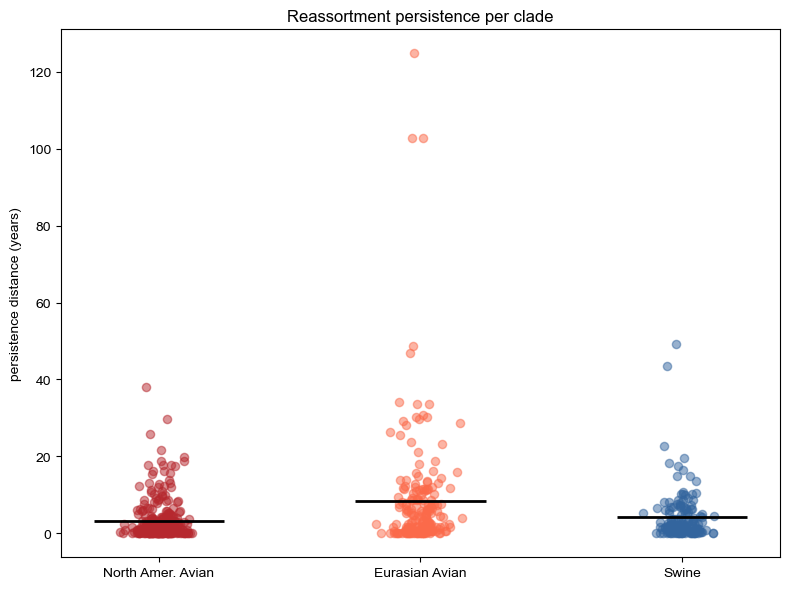

In [51]:
groups = ["North Amer. Avian", "Eurasian Avian", "Swine"]
data = [na_avian_persistences, eu_avian_persistences, swine_persistences]

color_map = {
    "North Amer. Avian": "#b6282e",
    "Eurasian Avian": "#fb6a4a", 
    "Swine": "#33659e"
    }

x = np.arange(len(groups))

plt.figure(figsize=(8, 6))

for i, (group, vals) in enumerate(zip(groups, data)):
    color = color_map[group]
    
    jitter = np.random.normal(0, 0.05, size=len(vals))
    plt.scatter(
        np.full(len(vals), x[i]) + jitter,
        vals,
        color=color,
        alpha=0.5,
        s=35
    )

    mean_val = np.mean(vals)
    plt.hlines(
        mean_val,
        x[i] - 0.25,
        x[i] + 0.25,
        colors="black",
        linewidth=2
    )

plt.xticks(x, groups)
plt.ylabel("persistence distance (years)")
plt.title("Reassortment persistence per clade")
plt.tight_layout()
plt.show()


In [52]:
def summarize(x):
    zero_count = sum(1 for val in x if val == 0.0)
    zero_prop = zero_count / len(x)
    
    return {
        "mean": np.mean(x),
        "sd": np.std(x, ddof=1),
        "median": np.median(x),
        "zeros": (zero_count, zero_prop)
    }

na_avian_stats = summarize(na_avian_persistences)
eu_avian_stats = summarize(eu_avian_persistences)
swine_stats = summarize(swine_persistences)

print("NA Avian:")
for k, v in na_avian_stats.items():
    if k == "zeros":
        print(f"  {k}: {v[0]}/{len(na_avian_persistences)} ({v[1]*100:.2f}%)")
    else:
        print(f"  {k}: {v:.2f}")
print(f"{len(na_avian_persistences)} lineages\n")
    
print("Eurasian Avian:")
for k, v in eu_avian_stats.items():
    if k == "zeros":
        print(f"  {k}: {v[0]}/{len(eu_avian_persistences)} ({v[1]*100:.2f}%)")
    else:
        print(f"  {k}: {v:.2f}")
print(f"{len(eu_avian_persistences)} lineages\n")

print("Swine:")
for k, v in swine_stats.items():
    if k == "zeros":
        print(f"  {k}: {v[0]}/{len(swine_persistences)} ({v[1]*100:.2f}%)")
    else:
        print(f"  {k}: {v:.2f}")
print(f"{len(swine_persistences)} lineages")

NA Avian:
  mean: 3.15
  sd: 5.10
  median: 1.22
  zeros: 69/306 (22.55%)
306 lineages

Eurasian Avian:
  mean: 8.37
  sd: 15.50
  median: 3.49
  zeros: 31/198 (15.66%)
198 lineages

Swine:
  mean: 4.22
  sd: 6.60
  median: 2.06
  zeros: 16/150 (10.67%)
150 lineages


In [53]:
na_avian_persistences

[13.16976734474501,
 1.2293666941983004,
 4.507677878727101,
 8.280561871266713,
 38.06797556517496,
 11.13495350607196,
 5.729979247096675,
 0.4097888980661001,
 3.2571152070426233,
 8.18164730966455,
 1.7451354796952883,
 0.0,
 3.871798554141773,
 2.5223213208551334,
 3.6810347567661745,
 3.2712458587000746,
 1.6391555922644003,
 0.0,
 4.076693003174824,
 1.2223013683695745,
 0.0,
 0.0,
 0.0,
 0.8125124703034743,
 0.8125124703034743,
 0.4097888980661001,
 3.2783111845288007,
 0.4097888980661001,
 1.2223013683695745,
 0.0,
 0.8195777961322002,
 12.272470964496822,
 0.0,
 6.274009335908567,
 0.8195777961322002,
 1.2293666941983004,
 0.0,
 0.8195777961322002,
 0.8125124703034743,
 0.0,
 1.2717586491706554,
 0.0,
 3.264180532871349,
 0.0,
 0.4097888980661001,
 0.0,
 0.0,
 0.4097888980661001,
 0.0,
 0.0,
 0.0,
 0.0,
 0.4097888980661001,
 0.0,
 3.2924418361862524,
 5.991396302759532,
 0.8195777961322002,
 0.4097888980661001,
 1.660351569750578,
 1.2717586491706554,
 0.4097888980661001,
 0.

# nonreassorted lineages

In [54]:
nonrea_clade_persistences = {clade: {} for clade in host_trees.keys()}

for clade in clades:
    
    mytree = host_trees[clade] 
    nonreassortment_distances = {}
    
    for k in mytree.Objects:

        # skip leaves
        if k.is_leaf():
            continue

        # only look at nonreassorted nodes
        if k.is_node() and not k.traits.get('is_reassorted'):

            children = k.children

            # if both children are reassorted or leaves, take max length, skip recursion
            if all(child.traits.get('is_reassorted') or child.is_leaf() for child in children):

                max_child_length = max(child.length for child in children)
                
            else:

                child_path_lengths = [max_distance(child) for child in children]
                max_child_length = max(child_path_lengths)

            nonreassortment_distances[k.traits["label"]] = {
                "height": k.height,
                "div": max_child_length,
                "scaled_distance": max_child_length / host_stats[clade]["clock_rate"],
                "branch_length": k.length,
            }


    nonrea_clade_persistences[clade] = nonreassortment_distances


# both

In [55]:
scaled_clade_persistences = {
    clade: {node: vals["scaled_distance"] for node, vals in nodes.items()}
    for clade, nodes in clade_persistences.items()
}

scaled_nonrea_persistences = {
    clade: {node: vals["scaled_distance"] for node, vals in nodes.items()}
    for clade, nodes in nonrea_clade_persistences.items()
}

In [56]:
def get_binned_proportions(persistences):
    """
    persistences: list or array of numbers
    returns: (years, proportions)
    """
    persistences = np.array(list(persistences))
    binned = np.floor(persistences).astype(int)
    counts = Counter(binned)
    total = len(binned)
    years = np.array(sorted(counts.keys()))
    proportions = np.array([counts[y] / total for y in years])
    return years, proportions


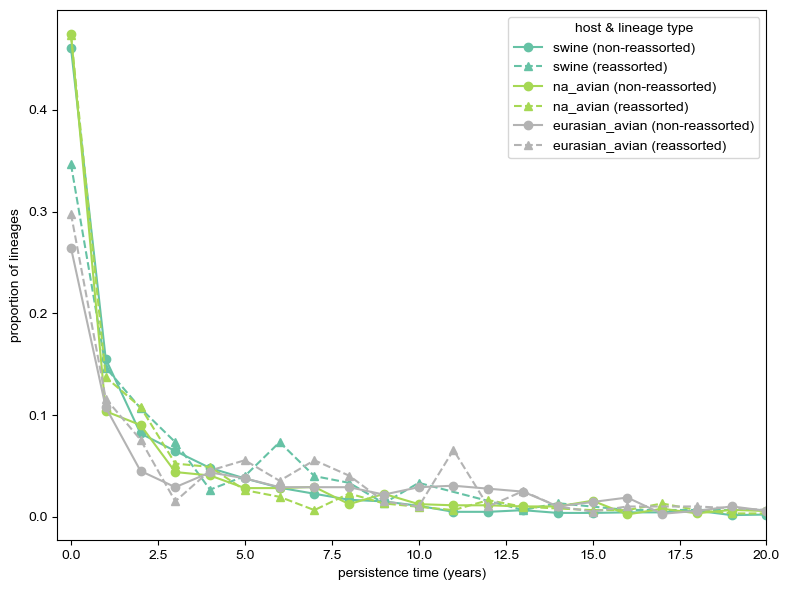

In [57]:
subset = ["swine", "na_avian", "eurasian_avian"]

colors = dict(zip(
    subset,
    plt.cm.Set2(np.linspace(0, 1, len(subset)))
))

plt.figure(figsize=(8, 6))

for clade in subset:
    
    # non-reassorted (circles)
    years, proportions = get_binned_proportions(scaled_nonrea_persistences[clade].values())
    plt.plot(
        years,
        proportions,
        marker="o",
        linestyle="-",
        color=colors[clade],
        label=f"{clade} (non-reassorted)"
    )

    # reassorted (triangles)
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    plt.plot(
        years,
        proportions,
        marker="^",
        linestyle="--",
        color=colors[clade],
        label=f"{clade} (reassorted)"
    )

plt.xlabel("persistence time (years)")
plt.ylabel("proportion of lineages")
plt.xlim(-0.4, 20)
plt.legend(title="host & lineage type")
plt.tight_layout()
plt.show()

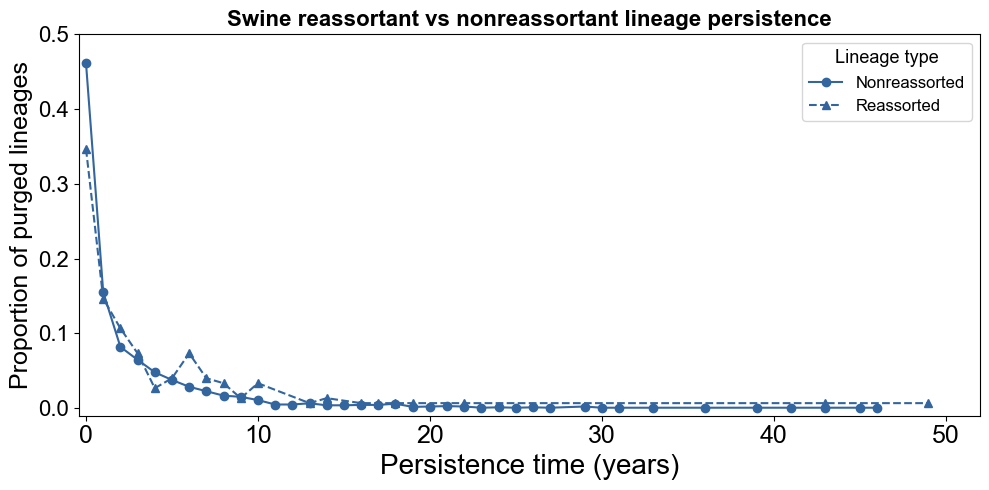

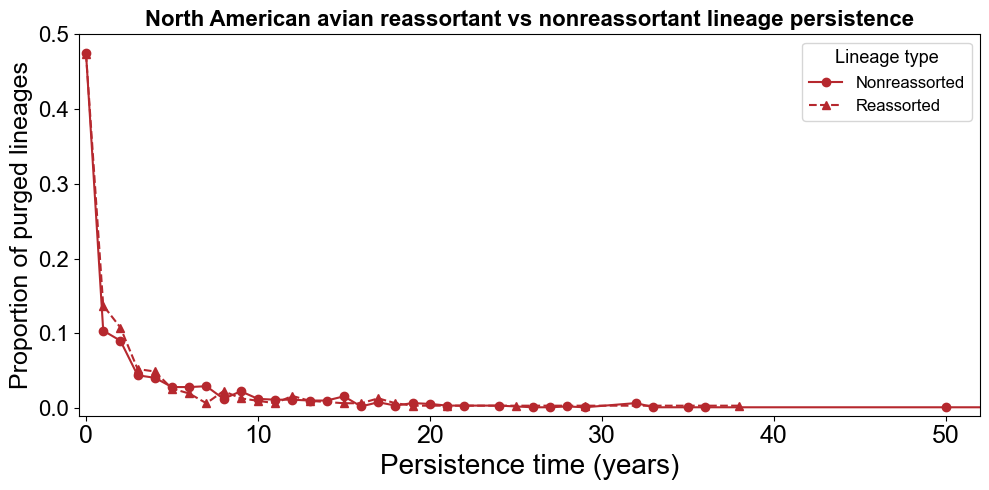

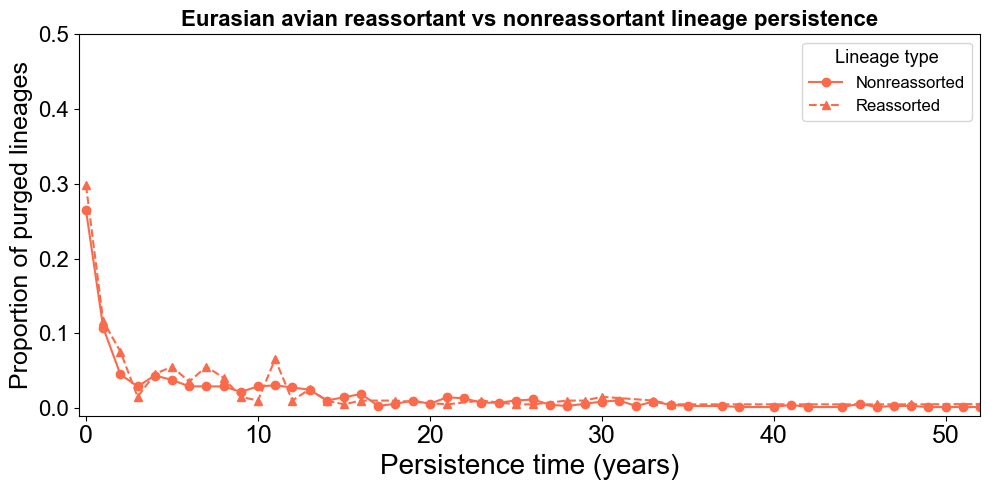

In [58]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'

subset = ["swine", "na_avian", "eurasian_avian"]

colors = {
    "na_avian": "#b6282e",
    "eurasian_avian": "#fb6a4a",
    "swine": "#33659e"
}

labels = {
    "na_avian": "North American avian",
    "eurasian_avian": "Eurasian avian",
    "swine": "Swine"
}

for clade in subset:
    plt.figure(figsize=(10, 5))

    # non-reassorted (circles)
    years, proportions = get_binned_proportions(scaled_nonrea_persistences[clade].values())
    plt.plot(
        years,
        proportions,
        marker="o",
        linestyle="-",
        color=colors[clade],
        label="Nonreassorted"
    )

    # reassorted (triangles)
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    plt.plot(
        years,
        proportions,
        marker="^",
        linestyle="--",
        color=colors[clade],
        label="Reassorted"
    )

    plt.xlabel("Persistence time (years)", fontsize=20)
    plt.ylabel("Proportion of purged lineages", fontsize=18)
    plt.title(
        f"{labels[clade]} reassortant vs nonreassortant lineage persistence",
        fontsize=16,
        fontweight="bold"
    )
    plt.xlim(-0.4, 52)
    plt.ylim(-0.01, 0.5)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=16)
    plt.legend(title="Lineage type", fontsize=12, title_fontsize=13)
    plt.tight_layout()
    plt.show()

# Reassorted persistences from shuffled, null datasets

In [ ]:
# produced in randomized_tree/reassortment_persistence.ipynb
with open("jsons/nonrea_clade_persistences.json", "r") as f:
    nonrea_clade_persistences = json.load(f)

with open("jsons/clade_persistences.json", "r") as f:
    clade_persistences = json.load(f)

In [60]:
def get_binned_proportions_replicates(all_replicates):
    """
    all_replicates: list of lists of persistence times for each replicate
    returns: bins (only bins that appear), mean_proportions, lower_ci, upper_ci
    """
    replicate_props = []
    replicate_bins = []

    for rep in all_replicates:
        rep = np.array(rep)
        binned = np.floor(rep).astype(int)
        counts = Counter(binned)
        total = len(binned)
        bins = np.array(sorted(counts.keys()))
        proportions = np.array([counts[b]/total for b in bins])
        replicate_props.append(proportions)
        replicate_bins.append(bins)

    all_bins = sorted(set(np.concatenate(replicate_bins))) # union of all bins
    mean_props = []
    lower_ci = []
    upper_ci = []

    for b in all_bins:
        props = np.array([rep_props[rep_bins.tolist().index(b)] if b in rep_bins else 0
                          for rep_props, rep_bins in zip(replicate_props, replicate_bins)])
        mean_props.append(props.mean())
        lower_ci.append(np.percentile(props, 5))
        upper_ci.append(np.percentile(props, 95))

    return np.array(all_bins), np.array(mean_props), np.array(lower_ci), np.array(upper_ci)


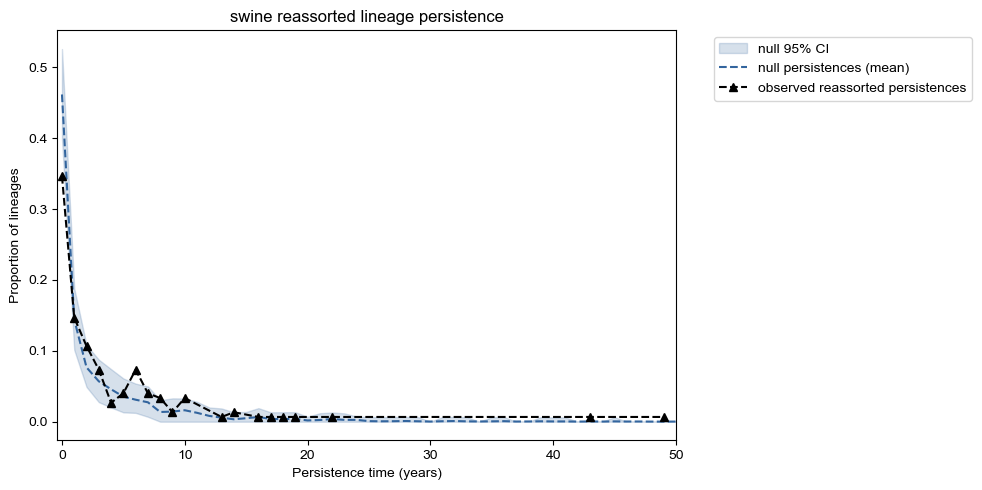

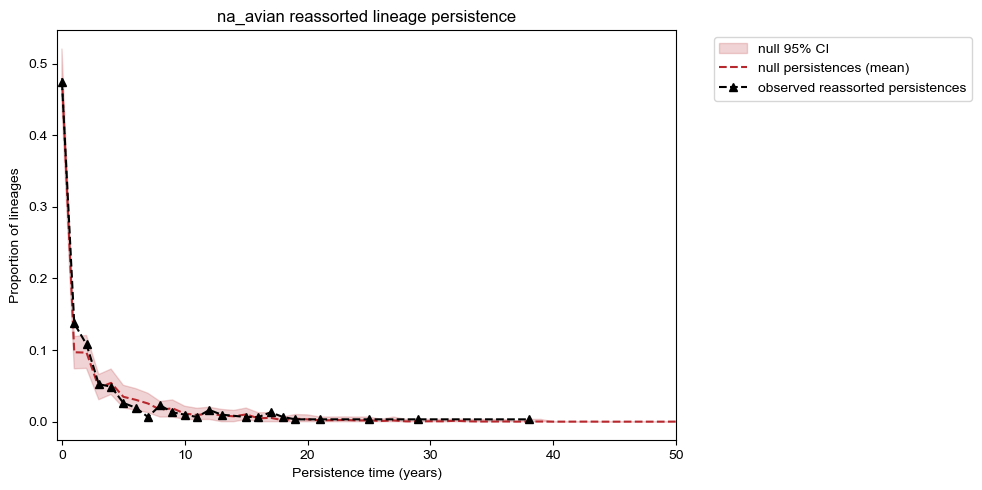

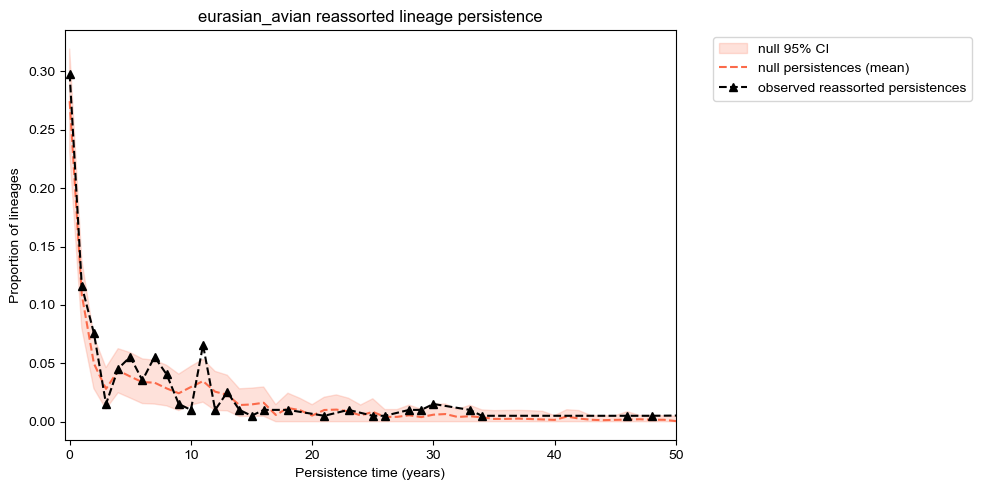

In [61]:
colors = {
    "na_avian": "#b6282e",
    "eurasian_avian": "#fb6a4a",
    "swine": "#33659e"
}

for clade in subset:
    plt.figure(figsize=(10, 5))

    # reassorted replicate mean + CI
    bins, mean_props, lower_ci, upper_ci = get_binned_proportions_replicates(
        clade_persistences[clade].values()
    )
    plt.fill_between(bins, lower_ci, upper_ci, color=colors[clade], alpha=0.2, label=f"null 95% CI")
    plt.plot(bins, mean_props, color=colors[clade], linestyle='--', label=f"null persistences (mean)")

    # reassorted scaled values (single values)
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    plt.plot(years, proportions, marker="^", linestyle="--", color='black', label=f"observed reassorted persistences")

    plt.xlabel("Persistence time (years)")
    plt.ylabel("Proportion of lineages")
    plt.title(f"{clade} reassorted lineage persistence")
    plt.xlim(-0.4, 50)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"plots/{clade}_persistences_vs_null.pdf", dpi=300, bbox_inches="tight")
    plt.show()

In [62]:
# 1-year proportions for each clade
for clade in subset:
    years, proportions = get_binned_proportions(scaled_clade_persistences[clade].values())
    prop_1yr = proportions[0]  # First bin (1 year)
    print(f"{clade}: {prop_1yr*100:.1f}% lineages purged in first year")

# for swine, get the null expectation at 1yr
clade = "swine"
bins, mean_props, lower_ci, upper_ci = get_binned_proportions_replicates(
    clade_persistences[clade].values()
)
idx_1yr = np.searchsorted(bins, 1.0)
null_mean_1yr = mean_props[idx_1yr]
obs_1yr = proportions[0]  # From above
difference = (null_mean_1yr - obs_1yr) * 100
print(f"Swine: {difference:.1f}% higher survival than null (observed: {obs_1yr*100:.1f}%, null: {null_mean_1yr*100:.1f}%)")

swine: 34.7% lineages purged in first year
na_avian: 47.4% lineages purged in first year
eurasian_avian: 29.8% lineages purged in first year
Swine: -15.4% higher survival than null (observed: 29.8%, null: 14.4%)
